# Salary Prediction Model

This notebook develops and evaluates a machine learning model to predict student salaries based on academic performance and placement status.

## Mission

I want to ensure all students have equal opportunities through removing barriers to gain access to resources necessary for learning successfully. A lot of our students do not have adequate means or support to have access to a variety of quality resources. Lack of access to these resources creates obstacles for students trying to develop their skills that will ultimately impact their future livelihood. I will work to establish alternate means of helping all students expand their learning through finding new or different ways to create options for gaining employment.

## Work Done Checklist

- [x] Specific, non-house prediction use case (salary prediction from `Placement.csv`).
- [x] Dataset suitability confirmed for regression analysis.
- [x] Various data visualizations generated (correlation heatmap, CGPA vs. Salary scatter plots, SGDRegressor loss curves).
- [x] Feature engineering performed (dropping `Student_ID`, handling categorical features).
- [x] Data converted to numeric types using `OneHotEncoder`.
- [x] Data standardized using `StandardScaler`.
- [x] Implemented Linear Regression, Decision Tree, Random Forest, and SGD Regressor models using `scikit-learn`.
- [x] Plotted loss curves for train/test data for SGDRegressor.
- [x] Plotted scatter plots with a fitted linear line (before and after regression).
- [x] Best-performing model saved using `joblib`.
- [x] Created prediction functions and demonstrated making predictions with the best model.

## Dataset Used

**Source:** [Kaggle: Student Placement Data with CGPA and Salary](https://www.kaggle.com/datasets/muhamedumarjamil/student-placement-data-with-cgpa-and-salary)

**Description:** This dataset contains information related to student placements, including academic performance (CGPA) and salary outcomes. It has 1000 rows and 5 columns, but for the purpose of this analysis, relevant columns are selected based on the prediction task (CGPA, Internships, Placed, Salary).

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

# 1. Load data
df = pd.read_csv("/content/sample_data/Placement.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   int64  
 1   CGPA              1000 non-null   float64
 2   Internships       1000 non-null   int64  
 3   Placed            1000 non-null   object 
 4   Salary (INR LPA)  1000 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 39.2+ KB


,Student_ID,CGPA,Internships,Salary (INR LPA)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,7.515560,2.045000,11.795580
std,288.819436,0.783422,1.424431,10.105559
min,1.000000,4.910000,0.000000,0.000000
25%,250.750000,6.980000,1.000000,0.000000
50%,500.500000,7.520000,2.000000,11.715000
75%,750.250000,8.020000,3.000000,20.935000
max,1000.000000,10.580000,4.000000,29.900000


### 1. Library Imports and Data Loading

This cell imports all necessary libraries for data manipulation, visualization, preprocessing, model building, and evaluation. It then loads the `Placement.csv` dataset into a pandas DataFrame and displays its head, info, and descriptive statistics.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

# 1. Load data
df = pd.read_csv("/content/sample_data/Placement.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   int64  
 1   CGPA              1000 non-null   float64
 2   Internships       1000 non-null   int64  
 3   Placed            1000 non-null   object 
 4   Salary (INR LPA)  1000 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 39.2+ KB


,Student_ID,CGPA,Internships,Salary (INR LPA)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,7.515560,2.045000,11.795580
std,288.819436,0.783422,1.424431,10.105559
min,1.000000,4.910000,0.000000,0.000000
25%,250.750000,6.980000,1.000000,0.000000
50%,500.500000,7.520000,2.000000,11.715000
75%,750.250000,8.020000,3.000000,20.935000
max,1000.000000,10.580000,4.000000,29.900000


### 2. Data Cleaning and Feature Selection

In [122]:
# Drop rows with missing Salary
df = df.dropna(subset=["Salary (INR LPA)"])

# Choose target and initial features
target_col = "Salary (INR LPA)"
feature_cols = ["Student_ID","CGPA", "Internships","Placed"]

X = df[feature_cols].copy()
y = df[target_col].copy()

### 3. Correlation Heatmap

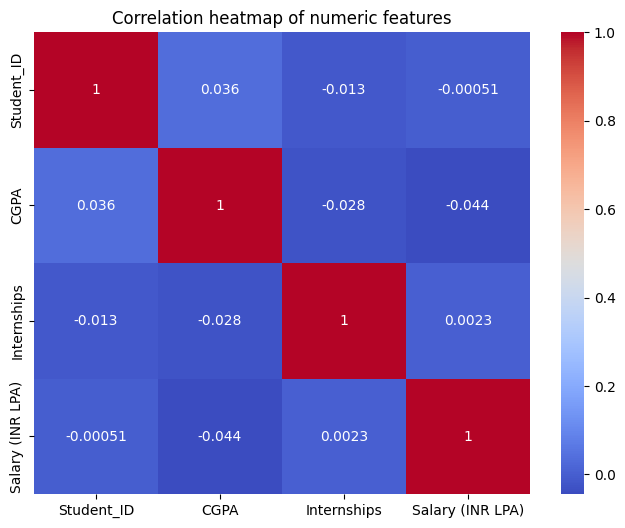

In [123]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap of numeric features")
plt.show()

### 4. CGPA vs. Salary Scatter Plot


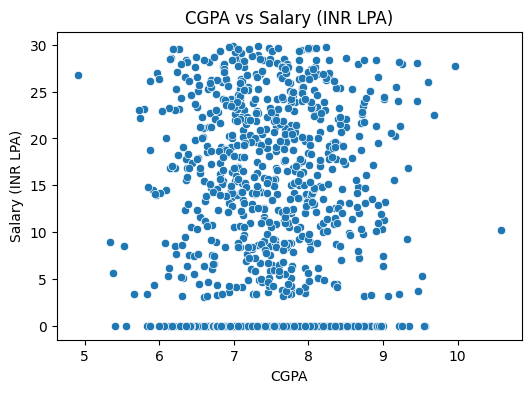

In [124]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="CGPA", y="Salary (INR LPA)")
plt.title("CGPA vs Salary (INR LPA)")
plt.show()

### 5. Feature Engineering and Data Splitting

In [125]:
# Features and target
X = df[["CGPA", "Internships", "Placed"]].copy()
y = df["Salary (INR LPA)"].copy()

numeric_features = ["CGPA", "Internships"]
categorical_features = ["Placed"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 6. Model Training and Initial Evaluation

In [126]:
models = {
    "linreg": LinearRegression(),
    "dt": DecisionTreeRegressor(random_state=42, max_depth=5),
    "rf": RandomForestRegressor(random_state=42, n_estimators=100, max_depth=7),
}

results = {}

for name, base_model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", base_model)
    ])
    pipe.fit(X_train, y_train);
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    results[name] = {
        "pipe": pipe,
        "train_mse": mean_squared_error(y_train, y_train_pred),
        "test_mse": mean_squared_error(y_test, y_test_pred),
    }

results

{'linreg': {'pipe': Pipeline(steps=[('preprocess',
                   ColumnTransformer(transformers=[('num', StandardScaler(),
                                                    ['CGPA', 'Internships']),
                                                   ('cat',
                                                    OneHotEncoder(drop='first',
                                                                  handle_unknown='ignore'),
                                                    ['Placed'])])),
                  ('model', LinearRegression())]),
  'train_mse': 40.20253887219661,
  'test_mse': 36.71146534484024},
 'dt': {'pipe': Pipeline(steps=[('preprocess',
                   ColumnTransformer(transformers=[('num', StandardScaler(),
                                                    ['CGPA', 'Internships']),
                                                   ('cat',
                                                    OneHotEncoder(drop='first',
                                   

### 7. Decision Tree Regressor Evaluation

In [127]:
dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=5))
])

dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

mse_train_dt = mean_squared_error(y_train, y_train_pred_dt)
mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
r2_train_dt = r2_score(y_train, y_train_pred_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)

mse_train_dt, mse_test_dt, r2_train_dt, r2_test_dt

(36.46819973106312, 38.905813824430865, 0.6436287570054153, 0.6138225125224537)

### 8. Random Forest Regressor Evaluation


In [128]:
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100, random_state=42, max_depth=7
    ))
])

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

mse_train_rf, mse_test_rf, r2_train_rf, r2_test_rf

(31.227509518105354,
 40.225322507876825,
 0.6948413559029281,
 0.6007251242920606)

### 9. SGDRegressor Training and Loss Curves

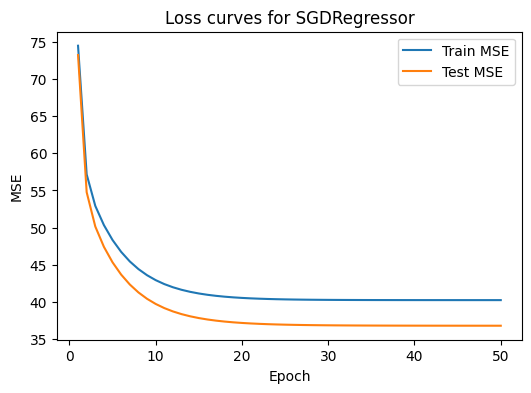

In [147]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sgd_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SGDRegressor(max_iter=1, warm_start=True, penalty=None, learning_rate="constant", eta0=0.001, random_state=42))
])

train_losses = []
test_losses = []

for epoch in range(1, 51):
    sgd_reg.fit(X_train, y_train)
    y_train_pred = sgd_reg.predict(X_train)
    y_test_pred = sgd_reg.predict(X_test)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(6, 4))
plt.plot(range(1, 51), train_losses, label="Train MSE")
plt.plot(range(1, 51), test_losses, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss curves for SGDRegressor")
plt.legend()
plt.show()

### 10. Visualization of Fitted Linear Regression Line

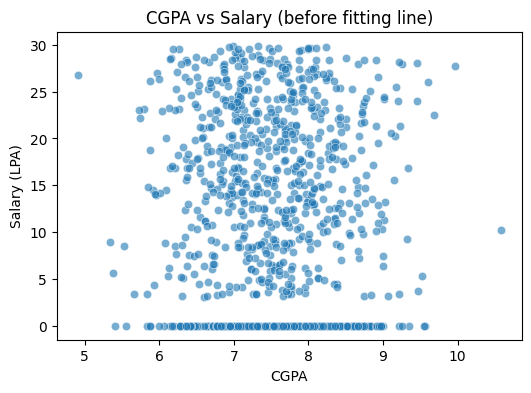

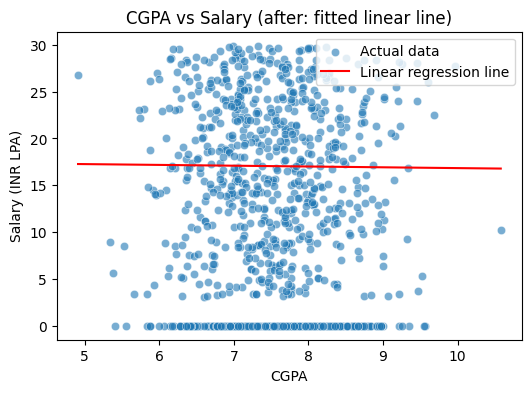

In [130]:
# Before raw data
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="CGPA", y="Salary (INR LPA)", alpha=0.6)
plt.title("CGPA vs Salary (before fitting line)")
plt.xlabel("CGPA")
plt.ylabel("Salary (LPA)")
plt.show()

# After regression line using the linear regression pipeline
linreg_pipe = results["linreg"]["pipe"]

cgpa_range = np.linspace(df["CGPA"].min(), df["CGPA"].max(), 100)
viz_df = pd.DataFrame({
    "CGPA": cgpa_range,
    "Internships": df["Internships"].median(),
    "Placed": df["Placed"].mode()[0]
})

salary_line = linreg_pipe.predict(viz_df)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="CGPA", y="Salary (INR LPA)", alpha=0.6, label="Actual data")
plt.plot(cgpa_range, salary_line, color="red", label="Linear regression line")
plt.title("CGPA vs Salary (after: fitted linear line)")
plt.xlabel("CGPA")
plt.ylabel("Salary (INR LPA)")
plt.legend()
plt.show()

### 11. Saving the Best Model

In [131]:
best_name = min(results, key=lambda k: results[k]["test_mse"])
best_model = results[best_name]["pipe"]

joblib.dump(best_model, "best_salary_model.joblib")
best_name

'linreg'

### 12. Loading and Testing the Best Model

In [132]:
loaded = joblib.load("best_salary_model.joblib")

one_row = X_test.iloc[[0]]
true_y = y_test.iloc[0]
pred_y = loaded.predict(one_row)[0]

print("Best model:", best_name)
print("Input features:\n", one_row)
print("True salary:", true_y)
print("Predicted salary:", pred_y)

Best model: linreg
Input features:
      CGPA  Internships Placed
521  7.93            1    Yes
True salary: 25.49
Predicted salary: 17.04387847032937


### 13. Prediction Functions and Example Usage


In [144]:
def load_model(model_path: str):
    return joblib.load(model_path)

def make_prediction(model, cgpa: float, internships: int, placement_status: str):
    # Build a one-row DataFrame with the same columns as training
    data = pd.DataFrame(
        {
            "CGPA": cgpa,
            "Internships": internships,
            "Placed": placement_status
        },
        index=[0]
    )
    pred = model.predict(data)[0]
    return pred

model = load_model("best_salary_model.joblib")

# Provide example values for prediction
cgpa_example = 8.5
internships_example = 2
placement_status_example = "Yes"

prediction = make_prediction(model, cgpa_example, internships_example, placement_status_example)
print(f"Predicted salary (LPA) for CGPA={cgpa_example}, Internships={internships_example}, Placed={placement_status_example}: {prediction}")


Predicted salary (LPA) for CGPA=8.5, Internships=2, Placed=Yes: 16.959704677375584
